In [1]:
import numpy as np
import pandas as pd
import xarray as xr

ds = xr.open_dataset("merged_32x32.nc")
pre_data = np.load("preci_32.npz", allow_pickle=True)
X_pre = pre_data["X"]
time_pre = pd.to_datetime(pre_data["time"])

lat_slice = slice(0, 10)
lon_slice = slice(8, 16)

chl_da = ds["chl"].isel(latitude=lat_slice, longitude=lon_slice)
chl_sel = chl_da.sel(time=time_pre)
chl_box = chl_sel.mean(dim=("latitude", "longitude")).values

prec_box = np.nanmean(X_pre[:, lat_slice, lon_slice, 0], axis=(1, 2))

df = pd.DataFrame({"time": time_pre, "chl": chl_box, "prec": prec_box})
df = df.set_index("time").sort_index()
df["prec_14d"] = df["prec"].rolling(14, min_periods=1).sum()
df["month"] = df.index.month

vars_ocean = ["thetao", "so", "no3", "po4", "si", "o2", "nppv"]
for v in vars_ocean:
    da_v = ds[v].isel(latitude=lat_slice, longitude=lon_slice)
    da_v_sel = da_v.sel(time=time_pre)
    df[v] = da_v_sel.mean(dim=("latitude", "longitude")).values

df["N_P_ratio"] = df["no3"] / df["po4"]
df["Si_N_ratio"] = df["si"] / df["no3"]

df_all = df.dropna()
print(df_all.head())
print(df_all.columns)


                 chl          prec  prec_14d  month     thetao         so  \
time                                                                        
2014-01-03  1.095409 -2.047970e-02 -0.020480      1  18.931520  35.914679   
2014-01-04  1.298192 -9.891389e-17 -0.020480      1  18.930375  36.047688   
2014-01-06  1.298294  4.995311e+00  4.974831      1  18.766976  35.982312   
2014-01-07  1.402788  1.615787e-03  4.976447      1  18.157670  35.890774   
2014-01-08  1.369935  8.133887e-02  5.057786      1  17.913745  35.909842   

                 no3       po4        si          o2       nppv  N_P_ratio  \
time                                                                         
2014-01-03  0.199871  0.017965  4.297507  227.235306  30.073009  11.125333   
2014-01-04  0.194015  0.012686  4.225826  228.662195  25.745980  15.294067   
2014-01-06  0.198527  0.015101  4.290098  229.623587  24.372000  13.146341   
2014-01-07  0.219318  0.012603  4.350187  230.913595  28.886179  17.40

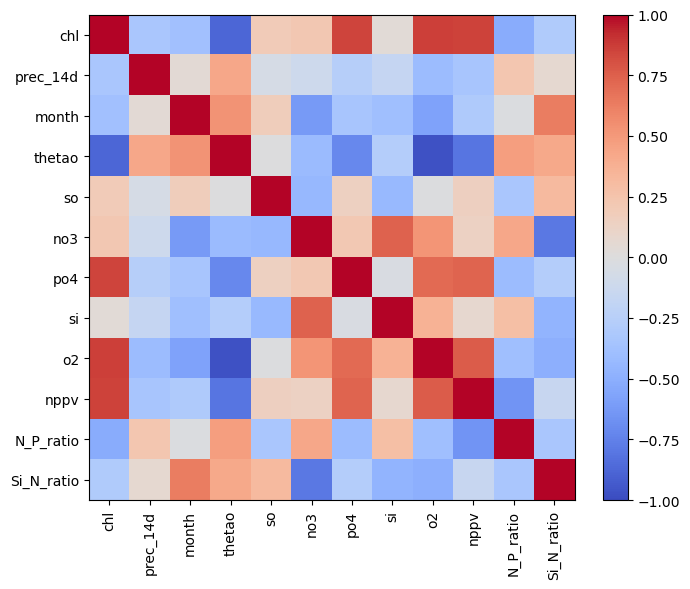

In [2]:
import matplotlib.pyplot as plt

cols_corr = ["chl", "prec_14d", "month"] + vars_ocean + ["N_P_ratio", "Si_N_ratio"]
corr = df_all[cols_corr].corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(cols_corr)), cols_corr, rotation=90)
plt.yticks(range(len(cols_corr)), cols_corr)
plt.tight_layout()
plt.show()


In [3]:
import statsmodels.api as sm

features_core = ["prec_14d", "month", "po4", "nppv", "o2"]
X_core = df_all[features_core]
y_core = df_all["chl"]

Xc_sm = sm.add_constant(X_core)
model_core = sm.OLS(y_core, Xc_sm).fit()
print(model_core.summary())


                            OLS Regression Results                            
Dep. Variable:                    chl   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     5907.
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:08:07   Log-Likelihood:                 3123.5
No. Observations:                3216   AIC:                            -6235.
Df Residuals:                    3210   BIC:                            -6198.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1187      0.052    -40.875      0.0

In [5]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

ds = xr.open_dataset("merged_32x32.nc")
pre_data = np.load("preci_32.npz", allow_pickle=True)
time_pre = pd.to_datetime(pre_data["time"])

lat_slice = slice(0, 10)
lon_near = slice(0, 6)
lon_mid = slice(6, 12)
lon_off = slice(12, 18)

chl_near = ds["chl"].isel(latitude=lat_slice, longitude=lon_near).sel(time=time_pre).mean(dim=("latitude", "longitude")).values
chl_mid = ds["chl"].isel(latitude=lat_slice, longitude=lon_mid).sel(time=time_pre).mean(dim=("latitude", "longitude")).values
chl_off = ds["chl"].isel(latitude=lat_slice, longitude=lon_off).sel(time=time_pre).mean(dim=("latitude", "longitude")).values

df_box = pd.DataFrame(
    {
        "time": time_pre,
        "chl_near": chl_near,
        "chl_mid": chl_mid,
        "chl_off": chl_off,
    }
).set_index("time").dropna()


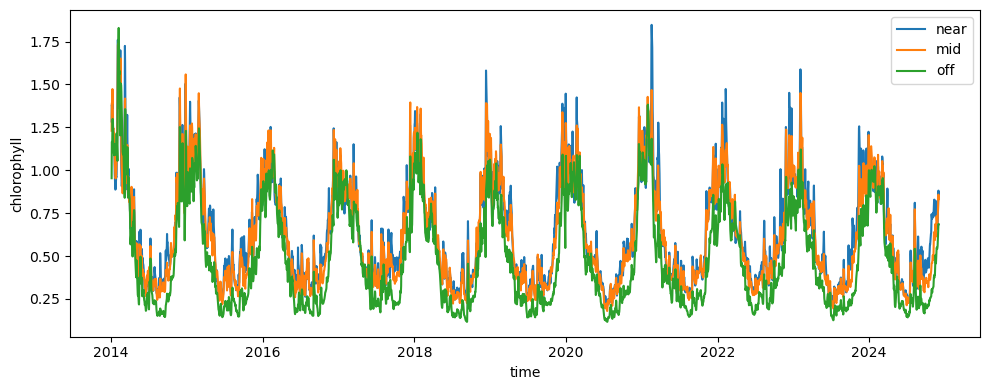

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(df_box.index, df_box["chl_near"], label="near")
plt.plot(df_box.index, df_box["chl_mid"], label="mid")
plt.plot(df_box.index, df_box["chl_off"], label="off")
plt.xlabel("time")
plt.ylabel("chlorophyll")
plt.legend()
plt.tight_layout()
plt.show()
